## Collect All `jpeg images` from Dataset Subdirectories

In [154]:
from pathlib import Path

# Path object to the dataset folder
dataset_image_path = Path("Helmet Detect")

# Recursively find all .jpg files in 'Helmet Detect' and all its subfolders (test, train, valid)
images_paths_lst = list(dataset_image_path.glob("**/*.jpg"))

## Dataset Cleanup: Remove `_png.rf.*` from Image Names

In [155]:
# Flag to track if we've already printed the "already desired format" message
already_desired_format = False

for path in images_paths_lst:
    
    # Check if filename contains "_png" (needs cleaning)
    if "_png" in path.stem:
        
        # Extract clean filename: remove everything after "_png" from the stem
        clean_name = path.stem.split("_png")[0]
        
        # Create new path with same parent directory, clean name and original extensions which is .jpg
        new_path = path.parent / (clean_name + path.suffix)
        
        # Rename only if the new name is different from the old name
        if path.name != new_path.name:
            
            # rename the file
            path.rename(new_path)
            print(f'Renamed: {path.name} -> {new_path.name}')
            
    elif not already_desired_format:
        print("Already desired format")
        already_desired_format = True

Already desired format


## Collect All `txt files` from Dataset Subdirectories

In [156]:
from pathlib import Path

# Path object to the dataset folder
dataset_label_path = Path("Helmet Detect")

# Recursively find all .txt files in 'Helmet Detect' and all its subfolders (test, train, valid)
labels_paths_lst = list(dataset_label_path.glob("**/*.txt"))

## Dataset Cleanup: Remove `_png.rf.*` from TXT Names

In [157]:
# Flag to track if we've already printed the "already desired format" message
already_desired_format = False

for path in labels_paths_lst:
    
    # Check if filename contains "_png" (needs cleaning)
    if "_png" in path.stem:
        
        # Extract clean filename: remove everything after "_png" from the stem
        clean_name = path.stem.split("_png")[0]
        
        # Create new path with same parent directory, clean name and original extensions which is .txt
        new_path = path.parent / (clean_name + path.suffix)
        
        # Rename only if the new name is different from the old name
        if path.name != new_path.name:
            
            # rename the file
            path.rename(new_path)
            print(f'Renamed: {path.name} -> {new_path.name}')
            
    elif not already_desired_format:
        print("Already desired format")
        already_desired_format = True

Already desired format


## Load YAML Dataset Config & Override Relative Paths to Absolute

In [158]:
import yaml

data_config = yaml.safe_load(open('Helmet Detect/data.yaml'))

# Override relative paths with absolute paths for YOLO training
data_config["train"] = 'Helmet Detect/train/images'
data_config["val"] = 'Helmet Detect/valid/images'
data_config["test"] = 'Helmet Detect/test/images'

data_config

{'train': 'Helmet Detect/train/images',
 'val': 'Helmet Detect/valid/images',
 'test': 'Helmet Detect/test/images',
 'nc': 2,
 'names': ['With Helmet', 'Without Helmet'],
 'roboflow': {'workspace': 'moeezs-workspace-gsui5',
  'project': 'helmet-detect-j6idy',
  'version': 1,
  'license': 'CC BY 4.0',
  'url': 'https://universe.roboflow.com/moeezs-workspace-gsui5/helmet-detect-j6idy/dataset/1'}}

In [167]:
class_names = data_config["names"]
class_names

['With Helmet', 'Without Helmet']

In [181]:
import glob

train_path = data_config['train']
images_paths_lst = list(dataset_image_path.glob("**/*.jpg"))
print(glob.glob(f"{train_path}/*.jpg")[:10])
print(30 * "_")
print(images_paths_lst[:5])

['Helmet Detect/train/images\\BikesHelmets10.jpg', 'Helmet Detect/train/images\\BikesHelmets100.jpg', 'Helmet Detect/train/images\\BikesHelmets101.jpg', 'Helmet Detect/train/images\\BikesHelmets104.jpg', 'Helmet Detect/train/images\\BikesHelmets106.jpg', 'Helmet Detect/train/images\\BikesHelmets107.jpg', 'Helmet Detect/train/images\\BikesHelmets108.jpg', 'Helmet Detect/train/images\\BikesHelmets11.jpg', 'Helmet Detect/train/images\\BikesHelmets110.jpg', 'Helmet Detect/train/images\\BikesHelmets111.jpg']
______________________________
[WindowsPath('Helmet Detect/test/images/BikesHelmets0.jpg'), WindowsPath('Helmet Detect/test/images/BikesHelmets102.jpg'), WindowsPath('Helmet Detect/test/images/BikesHelmets105.jpg'), WindowsPath('Helmet Detect/test/images/BikesHelmets109.jpg'), WindowsPath('Helmet Detect/test/images/BikesHelmets114.jpg')]


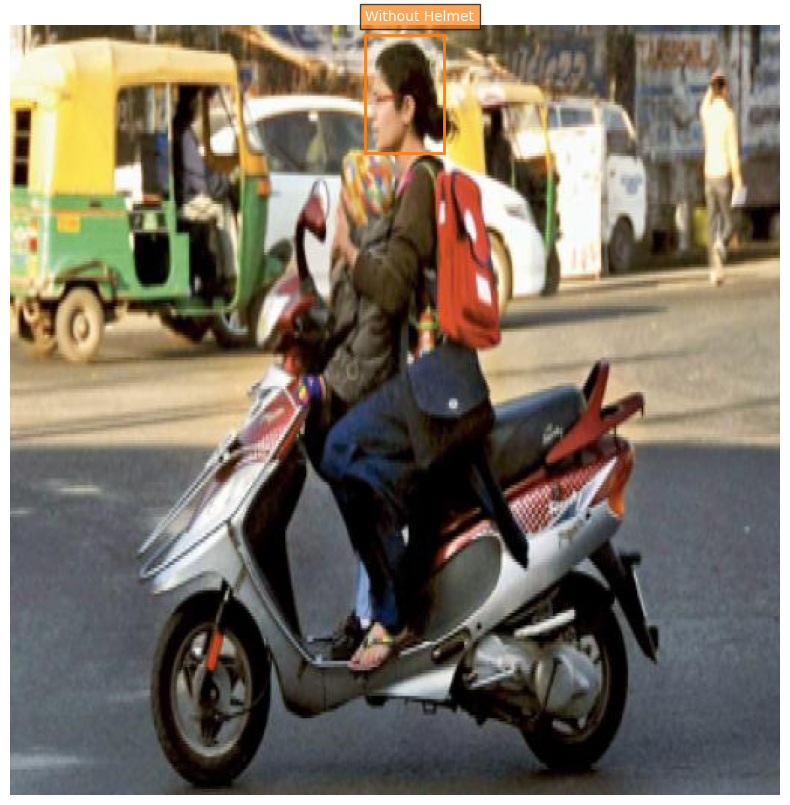

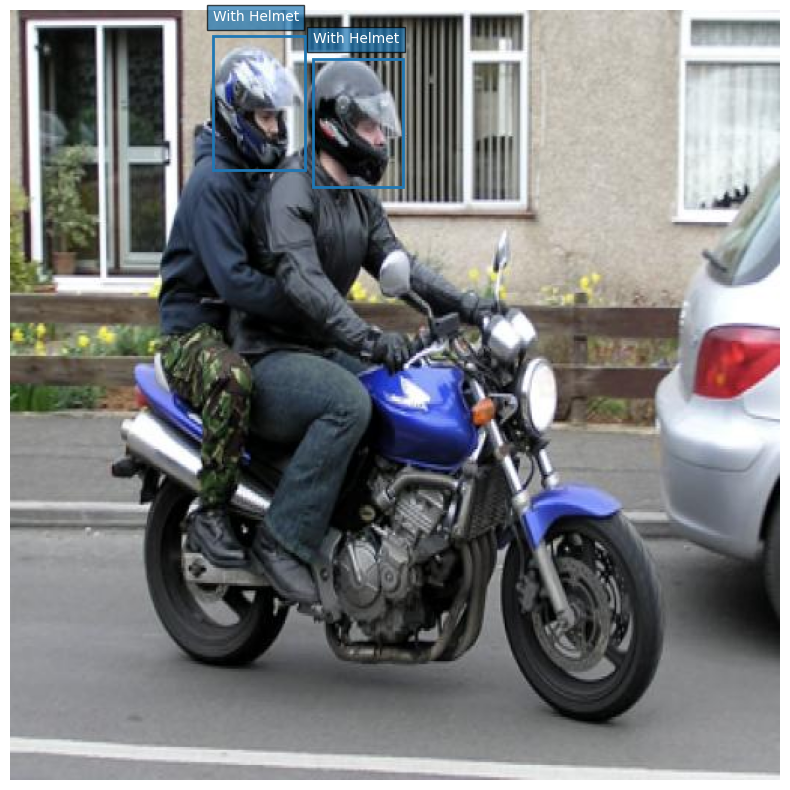

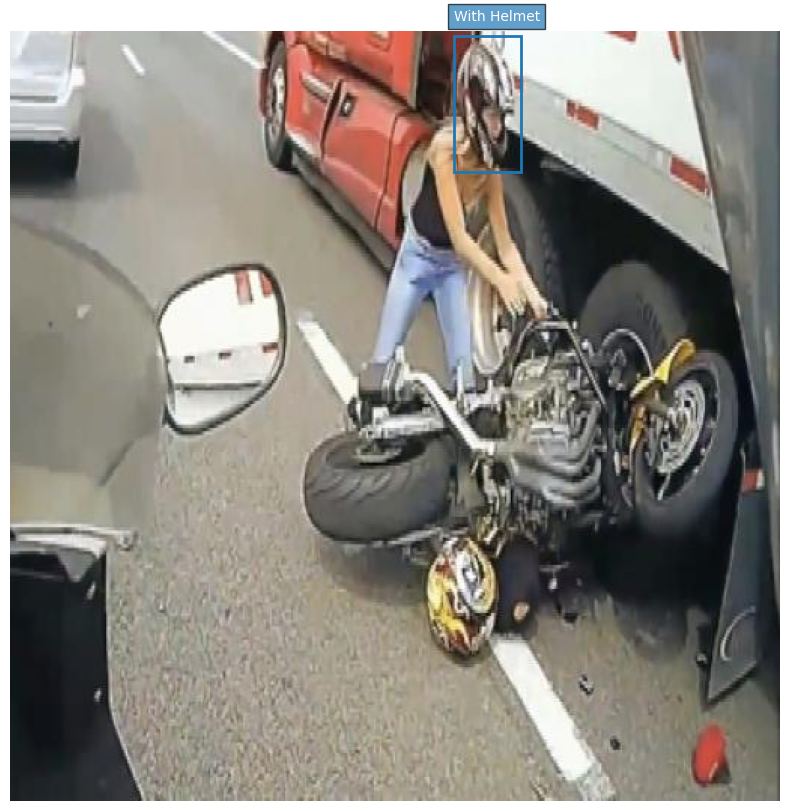

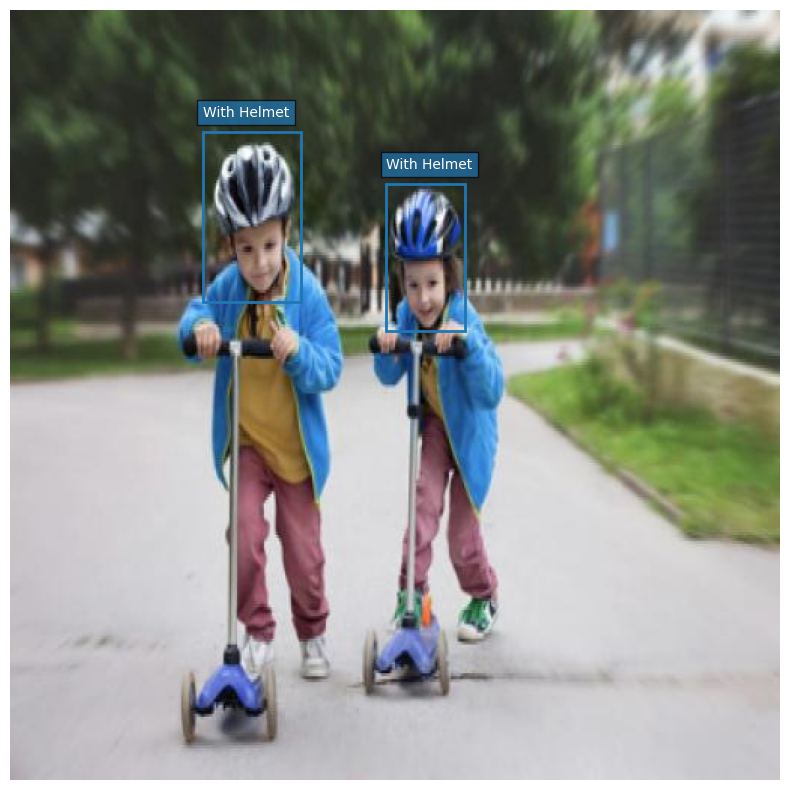

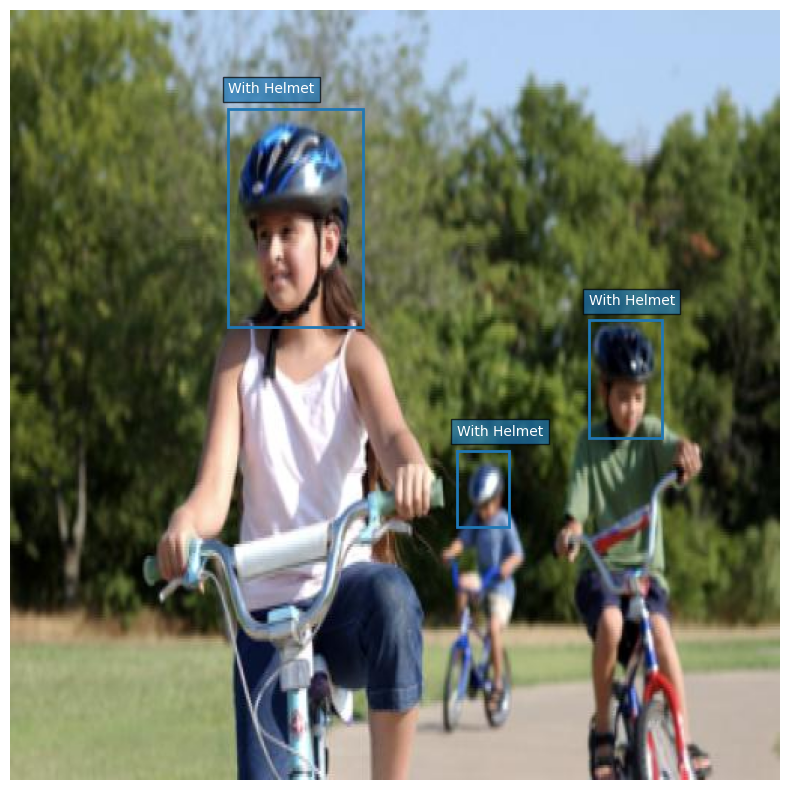

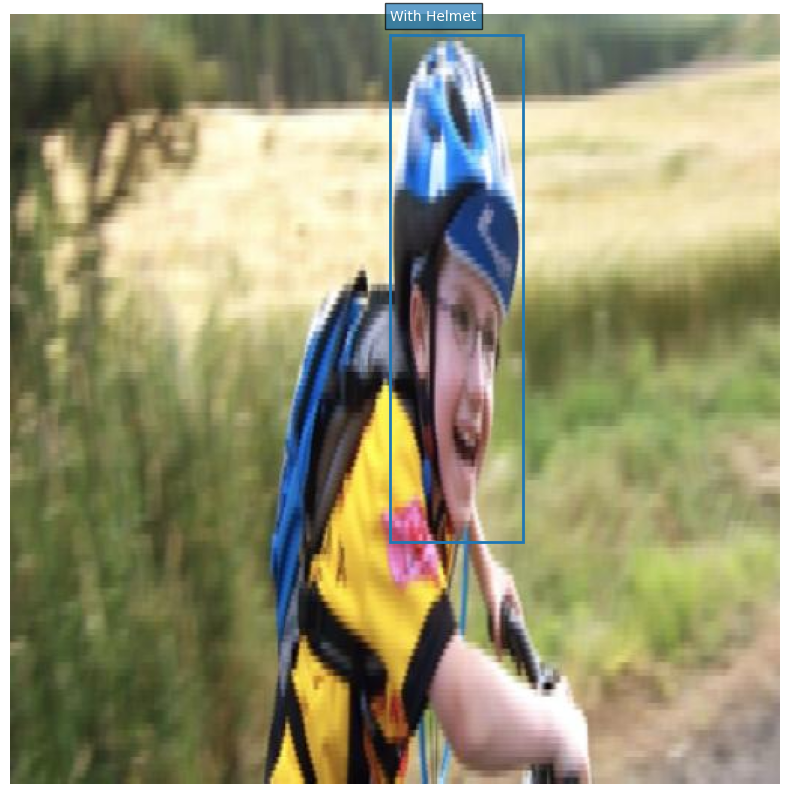

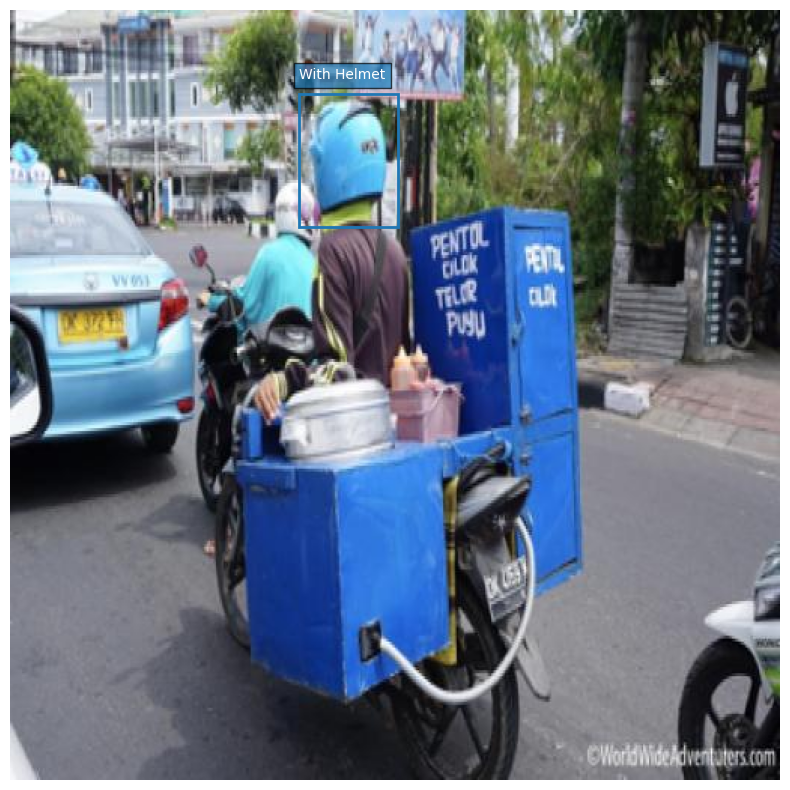

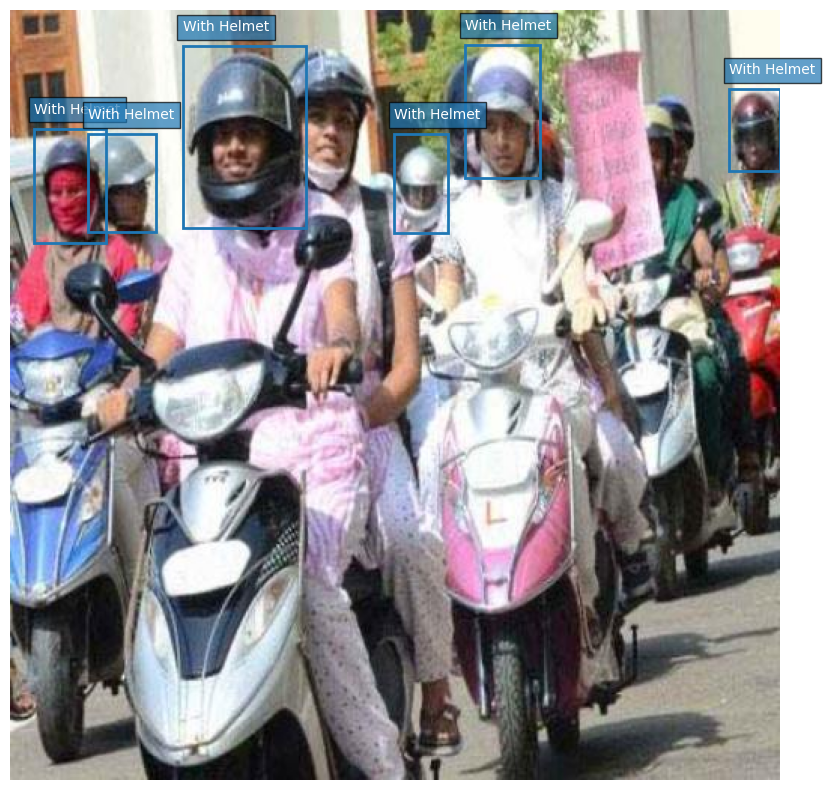

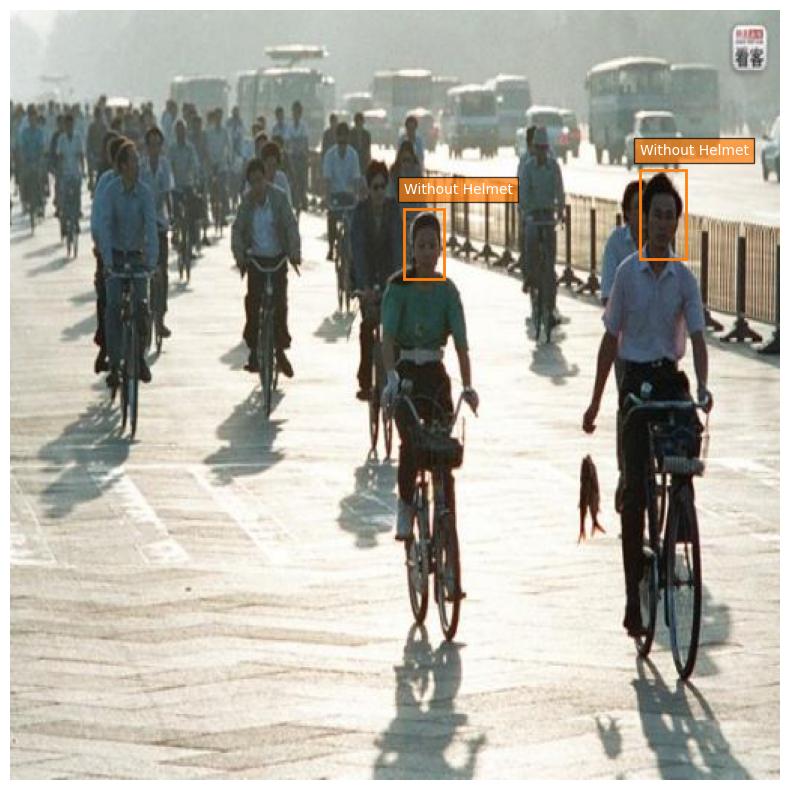

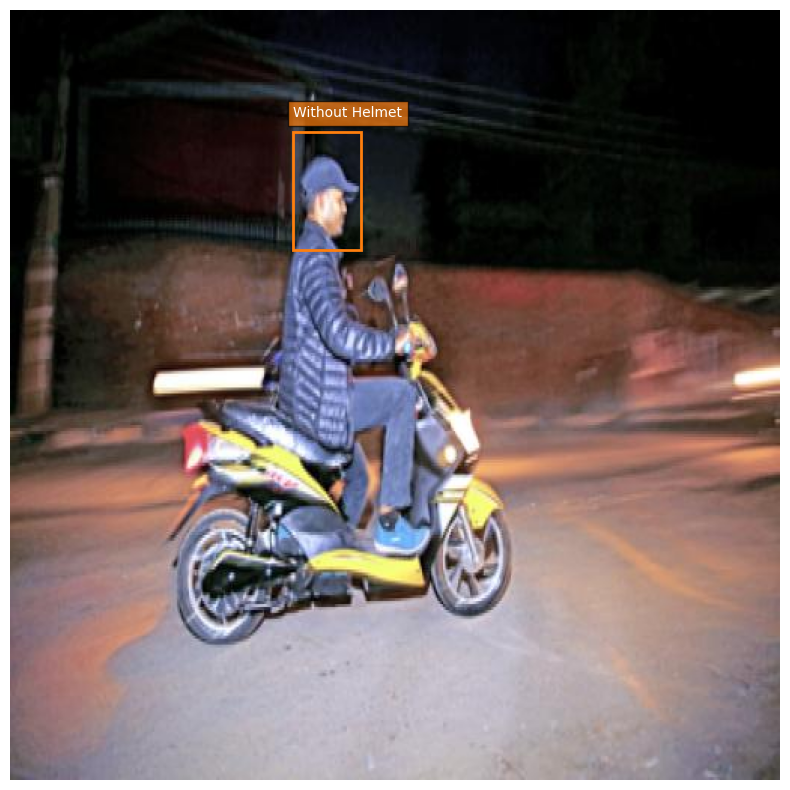

In [207]:
import glob
import cv2
import matplotlib.pyplot as plt
import os
from pathlib import Path  # ADD THIS - was missing

# Get class names from YAML config
class_names = data_config["names"]

# Get training images directory path
train_path = data_config['train']

# Load first 10 sample images from training folder
sample_images = glob.glob(f"{train_path}/*.jpg")[:10]

for img_path in sample_images:  # ONE loop only - removed the nested one
    
    # Load and Convert image (BGR to RGB)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Get image dimensions: height, width (ignore channels)
    h, w, _ = img.shape
    
    # Convert string path to Path object for easy manipulation
    image_path = Path(img_path)
    
    # Step 1: image_path.parent -> goes up from 'images/' to 'train/'
    # Step 2: / "labels" -> adds 'labels/' folder
    # Step 3: / (image_path.stem + ".txt") -> adds filename with .txt extension
    label_path = image_path.parent.parent / "labels" / (image_path.stem + ".txt")
        
    # If label exists: draw bounding boxes
    if os.path.exists(label_path):
        plt.figure(figsize=(10, 10))
        plt.imshow(img)
        ax = plt.gca()
        
        # Parse YOLO format: class x_center, y_center, width, height (normalized 0-1)
        with open(label_path) as f:
            for line in f:
                
                # Split line into 5 numbers: class_id, center_x, center_y, box_width, box_height
                # line.split() -> list of strings -> ["0", "0.5", "0.3", "0.2", "0.1"]
                # map(float, line.split()) -> list of floats -> [0.0, 0.5, 0.3, 0.2, 0.1]
                cls, xc, yc, bw, bh = map(float, line.split())
                
                # Scale normalized YOLO coordinates to absolute pixel values
                # (center_x, center_y, width, height) -> (x1, y1, x2, y2)
                
                # Left edge = (center - half_width) × image_width
                x1 = (xc - bw/2) * w

                # Right edge = (center + half_width) × image_width  
                x2 = (xc + bw/2) * w

                # Top edge = (center - half_height) × image_height
                y1 = (yc - bh/2) * h

                # Bottom edge = (center + half_height) × image_height
                y2 = (yc + bh/2) * h
                
                # Assign a unique color from matplotlib's tab10 colormap based on class ID
                # class 0 (with helmet) -> blue, class 1(without helmet) -> orange
                color = plt.cm.tab10(int(cls) % 10)
                
                # Create rectangle: top-left corner (x1,y1), width (x2-x1), height (y2-y1)
                rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                                     fill=False,        # Don't fill inside, just show outline 
                                     edgecolor=color,   # Border color (unique per class)
                                     linewidth=2)
                
                # Add the rectangle to the axes (image) so it appears on the plot
                ax.add_patch(rect)
                
                # Draw class label with colored background above bounding box
                plt.text(x1, y1-10,                    # Position: above box (10 pixels up)
                         class_names[int(cls)],        # Text: class name (e.g., "helmet")
                         color='white',                # Text color
                         fontsize=10,                  # Text size
                         bbox=dict(facecolor=color,    # Box background: same color as bounding box
                                   alpha=0.7))         # 70% opaque (semi-transparent)

        plt.axis('off')
        plt.show()

In [208]:
import glob
import cv2
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Get class names from YAML config
class_names = data_config["names"]

# Get training images directory path
train_path = data_config['train']

# Load first 10 sample images from training folder
sample_images = glob.glob(f"{train_path}/*.jpg")[:10]

print(f"Found {len(sample_images)} images")  # DEBUG: Check if images found
print(f"Train path: {train_path}")           # DEBUG: Check path

for img_path in sample_images:
    print(f"\nProcessing: {img_path}")  # DEBUG: Show current image
    
    # Load and Convert image (BGR to RGB)
    img = cv2.imread(img_path)
    if img is None:
        print(f"ERROR: Could not load {img_path}")  # DEBUG: Loading failed
        continue
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    print(f"Image size: {w}x{h}")  # DEBUG: Show dimensions
    
    # Build label path
    image_path = Path(img_path)
    label_path = image_path.parent / "labels" / (image_path.stem + ".txt")
    print(f"Looking for label: {label_path}")  # DEBUG: Show label path
    
    # If label exists: draw bounding boxes
    if os.path.exists(label_path):
        print(f"Label found! Drawing boxes...")  # DEBUG: Label exists
        plt.figure(figsize=(10, 10))
        plt.imshow(img)
        ax = plt.gca()
        
        with open(label_path) as f:
            lines = f.readlines()
            print(f"Number of boxes: {len(lines)}")  # DEBUG: Count boxes
            
            for line in lines:
                cls, xc, yc, bw, bh = map(float, line.split())
                print(f"Box: class={cls}, center=({xc},{yc}), size=({bw},{bh})")  # DEBUG: Box data
                
                x1 = (xc - bw/2) * w
                x2 = (xc + bw/2) * w
                y1 = (yc - bh/2) * h
                y2 = (yc + bh/2) * h
                
                color = plt.cm.tab10(int(cls) % 10)
                rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                                     fill=False, edgecolor=color, linewidth=2)
                ax.add_patch(rect)
                plt.text(x1, y1-10, class_names[int(cls)], 
                        color='white', fontsize=10,
                        bbox=dict(facecolor=color, alpha=0.7))
        
        plt.axis('off')
        plt.show()
        print("Display complete")  # DEBUG: Done
    else:
        print(f"Label NOT found: {label_path}")  # DEBUG: Missing label

Found 10 images
Train path: Helmet Detect/train/images

Processing: Helmet Detect/train/images\BikesHelmets10.jpg
Image size: 512x512
Looking for label: Helmet Detect\train\images\labels\BikesHelmets10.txt
Label NOT found: Helmet Detect\train\images\labels\BikesHelmets10.txt

Processing: Helmet Detect/train/images\BikesHelmets100.jpg
Image size: 512x512
Looking for label: Helmet Detect\train\images\labels\BikesHelmets100.txt
Label NOT found: Helmet Detect\train\images\labels\BikesHelmets100.txt

Processing: Helmet Detect/train/images\BikesHelmets101.jpg
Image size: 512x512
Looking for label: Helmet Detect\train\images\labels\BikesHelmets101.txt
Label NOT found: Helmet Detect\train\images\labels\BikesHelmets101.txt

Processing: Helmet Detect/train/images\BikesHelmets104.jpg
Image size: 512x512
Looking for label: Helmet Detect\train\images\labels\BikesHelmets104.txt
Label NOT found: Helmet Detect\train\images\labels\BikesHelmets104.txt

Processing: Helmet Detect/train/images\BikesHelmets